In [1]:
import snappy
import numpy as np
import matplotlib.pyplot as plt
from sympy.solvers import solve_linear
from sympy.plotting.plot_implicit import plot_implicit
from sympy.plotting.plot import List2DSeries
from sympy import Symbol, Abs, symbols
from invariants import *

In [2]:
def move_sympyplot_to_axes(p, ax):
    backend = p.backend(p)
    backend.ax = ax
    backend._process_series(backend._series[0], ax)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_position('zero')
    ax.set_xlabel(ax.get_xlabel(), ha='right', x=1, labelpad=0)
    ax.set_ylabel(ax.get_ylabel(), ha='right', va='top', y=1, labelpad=0, rotation=0)
    #import pdb; pdb.set_trace()
    #plt.close(backend.fig)

# Plot Knot Geography $T(p,q)$
Gordon-Litherland signature bound:
$$
W_\sigma = \left\{
2b \ge \left| e - 2\sigma(K) \right|
\right\}
$$

### TODO
- write a function to draw wedge regions for different invariants in the $e$-$b_1$ plane
- when $\sigma$ and $\upsilon$ are different, draw wedge regions for $T(4,q)$ in the $e$-$b_1$ plane
- For $T(4,5)$ try to find 2 band moves to the unknot ($\gamma_4(T(4,5)) = 2$ so we need exactly two bands) and compute their normal euler number and upsilon to place them in the wedge plot

In [16]:
def plot_sig_bound(K, erange=(-20,20), brange=(0,20)):
    sigma = K.signature()
    ups = upsilon(K)
    e_symb, b_symb = symbols('e b')

    int_points = [(e,b) 
                  for e in range(erange[0], erange[1]+1) 
                  for b in range(brange[0], brange[1]+1)]

    realizable_points = [(e,b) for e,b in int_points if 2*b >= abs(e - 2 * sigma)]
    realizable_e = [e for e,_ in realizable_points]
    realizable_b = [b for _,b in realizable_points]

    plot_implicit(2*b_symb >= Abs(e_symb - 2 * sigma),
                               range_x=(e_symb, erange[0], erange[1]), range_y=(b_symb, brange[0], brange[1]),
                               xlabel="$e$", ylabel="$b_1$", line_color="gray")
    plot_implicit(b_symb >= Abs(2 * ups - 0.5 * e_symb),
                               range_x=(e_symb, erange[0], erange[1]), range_y=(b_symb, brange[0], brange[1]),
                               xlabel="$e$", ylabel="$b_1$", line_color="gray")
    
    #fig, ax = plt.subplots()
    #move_sympyplot_to_axes(sympy_plot1, ax)
    #ax.scatter(realizable_e, realizable_b, s=2, c='red')

    #return sympy_plot1

### TODO - plot integer points
### TODO - fix axis label position

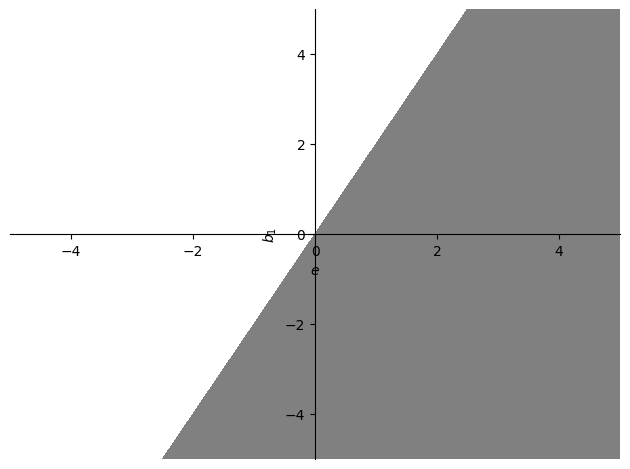

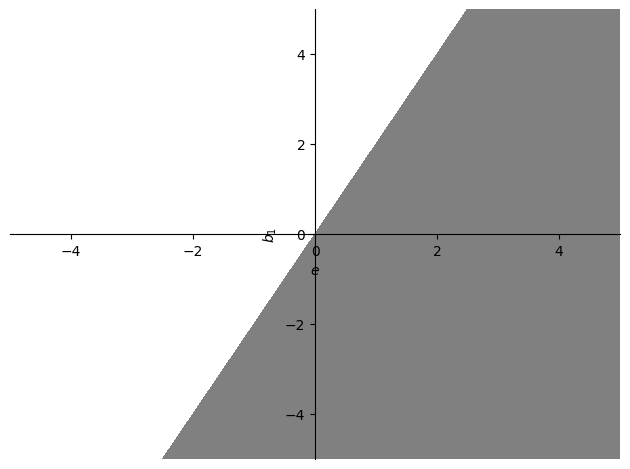

In [17]:
T45 = snappy.Link('T(4,5)')
p = plot_sig_bound(T45)

In [18]:
p.show()

AttributeError: 'NoneType' object has no attribute 'show'